<a href="https://colab.research.google.com/github/utkh-gt/grievance-nlp-system/blob/main/notebooks/Week3_Urgency_Scoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/Project 1/cleaned_data.csv")

## **Using Vader compound scoring for sentiment score**

In [2]:
!pip install vaderSentiment

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.4 MB/s eta 0:00:00


In [3]:
analyzer = SentimentIntensityAnalyzer()

df['sentiment_score'] = df['Text'].apply(
    lambda x: analyzer.polarity_scores(str(x))['compound']
)

print(df[['Text', 'sentiment_score']].head(10))

                       Text  sentiment_score
0  Street Light Not Working           0.0000
1  Street Light Not Working           0.0000
2              Garbage dump          -0.3818
3  Street Light Not Working           0.0000
4              Garbage dump          -0.3818
5  Street Light Not Working           0.0000
6  Street Light Not Working           0.0000
7  Street Light Not Working           0.0000
8              Garbage dump          -0.3818
9     footpath encroachment           0.0000


In [4]:
def score_to_priority(score):
    if score <= -0.5:
        return "Critical"
    elif score <= -0.1:
        return "High"
    elif score <= 0.2:
        return "Medium"
    else:
        return "Low"

df['priority'] = df['sentiment_score'].apply(score_to_priority)

print(df['priority'].value_counts())

priority
Medium      95088
High        24571
Low          4233
Critical     3082
Name: count, dtype: int64


## **Visualizing sentiment score distribution and priority count**

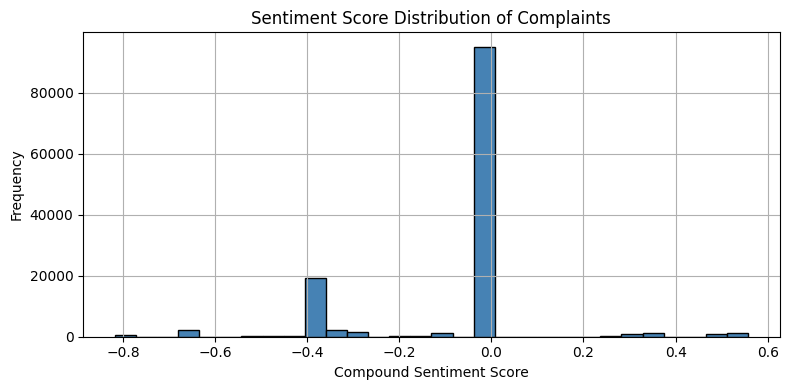

In [6]:
plt.figure(figsize=(8, 4))
df['sentiment_score'].hist(bins=30, color='steelblue', edgecolor='black')
plt.title('Sentiment Score Distribution of Complaints')
plt.xlabel('Compound Sentiment Score')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('sentiment_distribution.png')
plt.show()

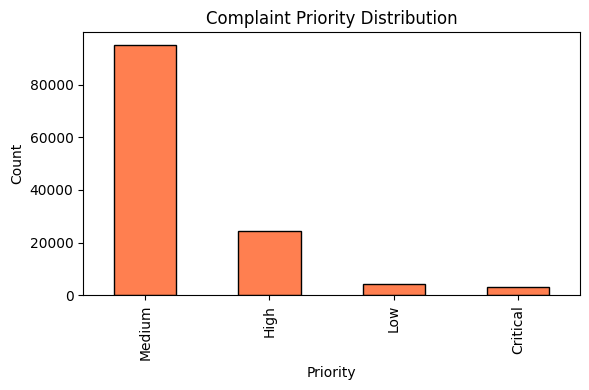

In [7]:
plt.figure(figsize=(6, 4))
df['priority'].value_counts().plot(kind='bar', color='coral', edgecolor='black')
plt.title('Complaint Priority Distribution')
plt.xlabel('Priority')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('priority_distribution.png')
plt.show()